# SMNIST Model Comparison: S4 vs LMU Across Data Fractions

This notebook compares S4 and LMU models trained on different fractions of the SMNIST dataset.

**Objectives:**
- Compare S4 vs LMU performance across different data sizes
- Analyze data efficiency (which model learns better with less data)
- Visualize learning curves
- Use **test set metrics** for final evaluation
- Identify the best model/fraction combination

**Fractions tested:** 10%, 25%, 50%, 100%


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root))

compare_folder = Path("figs")
compare_folder.mkdir(exist_ok=True)

print(f"Project root: {project_root}")

Project root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4


## Load Test Results

Load test_results.json from each run folder for both S4 and LMU models across all data fractions.


In [8]:
from src.eval.compare import load_all_experiments

base_dir = "./runs"
models = ['s4', 'lmu']
fractions = [0.1, 0.25, 0.5, 1.0]
task_name = "smnist"

print("="*60)
print("LOADING SMNIST EXPERIMENT RESULTS")
print("="*60)
print()

all_results = load_all_experiments(
    base_dir=base_dir,
    models=models,
    fractions=fractions,
    task_name=task_name
)

print()
print("="*60)
print("LOADING COMPLETE")
print("="*60)

for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"{model.upper()}: Loaded {n_loaded}/{len(fractions)} experiments")

LOADING SMNIST EXPERIMENT RESULTS

Loading S4 @ 10%: smnist_s4_task_frac_10
Loading S4 @ 25%: smnist_s4_task_frac_25
Loading S4 @ 50%: smnist_s4_task_frac_50
Loading S4 @ 100%: smnist_s4_task
Loading LMU @ 10%: smnist_lmu_task_frac_10
Loading LMU @ 25%: smnist_lmu_task_frac_25
Loading LMU @ 50%: smnist_lmu_task_frac_50
Loading LMU @ 100%: smnist_lmu_task

LOADING COMPLETE
S4: Loaded 4/4 experiments
LMU: Loaded 4/4 experiments


## Results Summary Table


In [3]:
from src.eval.compare import create_test_comparison_table

print()

test_comparison_df = create_test_comparison_table(
    all_results,
    metrics=['accuracy', 'loss']
)

pd.options.display.float_format = '{:.4f}'.format


print("\n" + "="*60)
print("BEST MODEL PER DATA FRACTION")
print("="*60)
for pct in sorted(test_comparison_df['data_pct'].unique()):
    subset = test_comparison_df[test_comparison_df['data_pct'] == pct]
    best_idx = subset['accuracy'].idxmax()
    best_row = subset.loc[best_idx]
    print(f"\n{pct}% data: {best_row['model']} (Accuracy: {best_row['accuracy']*100:.2f}%)")

print()
print(test_comparison_df)



BEST MODEL PER DATA FRACTION

10% data: LMU (Accuracy: 91.49%)

25% data: LMU (Accuracy: 93.01%)

50% data: LMU (Accuracy: 95.03%)

100% data: LMU (Accuracy: 98.70%)

  model  data_pct  accuracy   loss  num_samples
0   LMU        10    0.9149 0.3070        10000
1   LMU        25    0.9301 0.2449        10000
2   LMU        50    0.9503 0.2313        10000
3   LMU       100    0.9870 0.0420        10000
4    S4        10    0.7183 0.8352        10000
5    S4        25    0.8719 0.4268        10000
6    S4        50    0.9082 0.3109        10000
7    S4       100    0.9843 0.0538        10000


## Visualization: Test Accuracy Comparison

Compare test accuracy of S4 and LMU across different data fractions.


Plot saved to: figs/test_data_efficiency.png


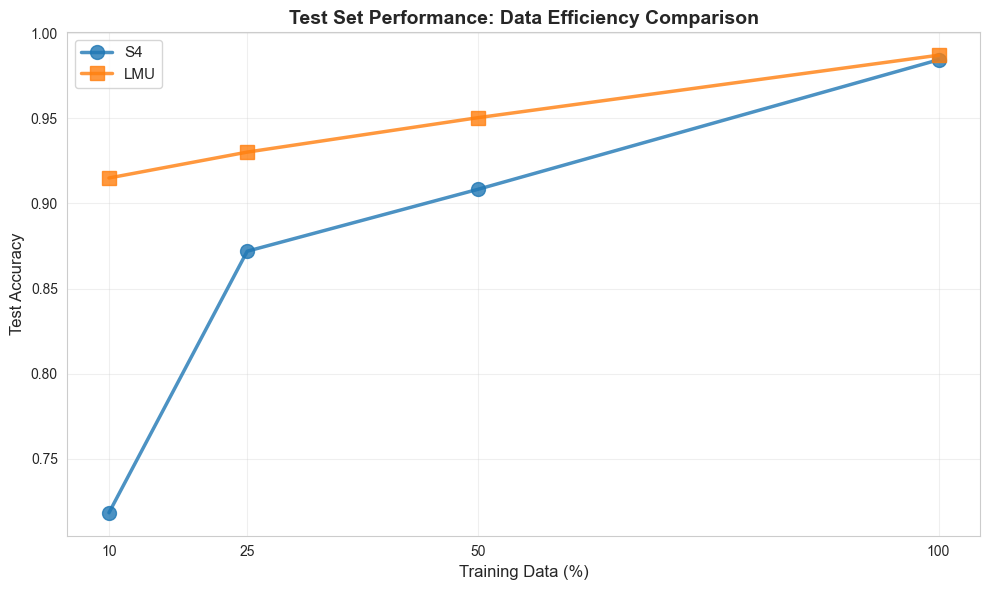

In [4]:
from src.eval.compare import plot_test_data_efficiency

plot_test_data_efficiency(
    all_results,
    metric_key='accuracy',
    ylabel='Test Accuracy',
    save_path=str(compare_folder / 'test_data_efficiency.png')
)

## Visualization: Test Loss Comparison

Compare test loss of S4 and LMU across different data fractions.


Plot saved to: figs/test_loss_comparison.png


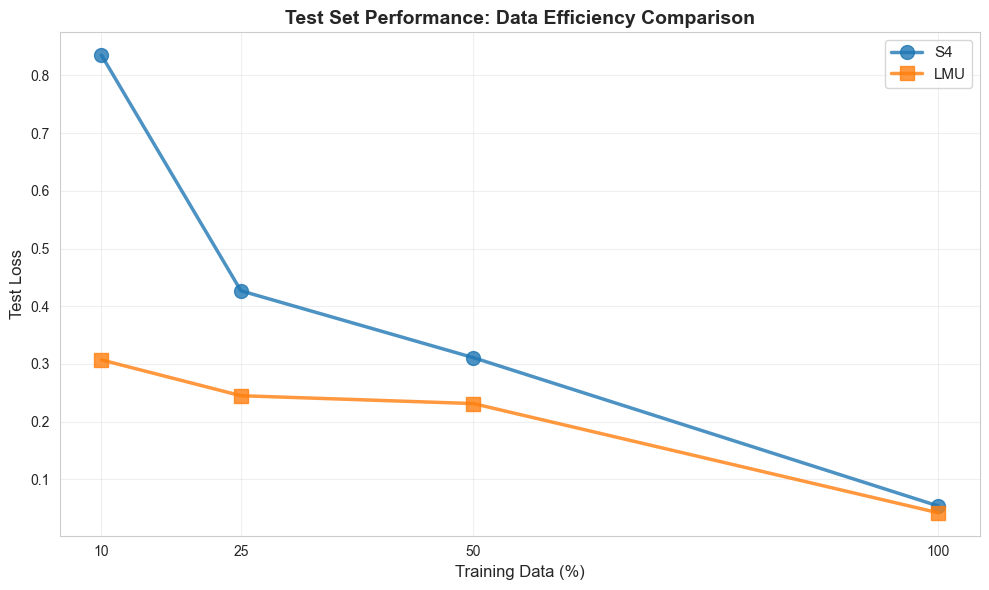

In [5]:
plot_test_data_efficiency(
    all_results,
    metric_key='loss',
    ylabel='Test Loss',
    save_path=str(compare_folder / 'test_loss_comparison.png')
)

## Bar Chart Comparison

Side-by-side comparison of test accuracy for each data fraction.


Plot saved to: figs/test_accuracy_comparison.png


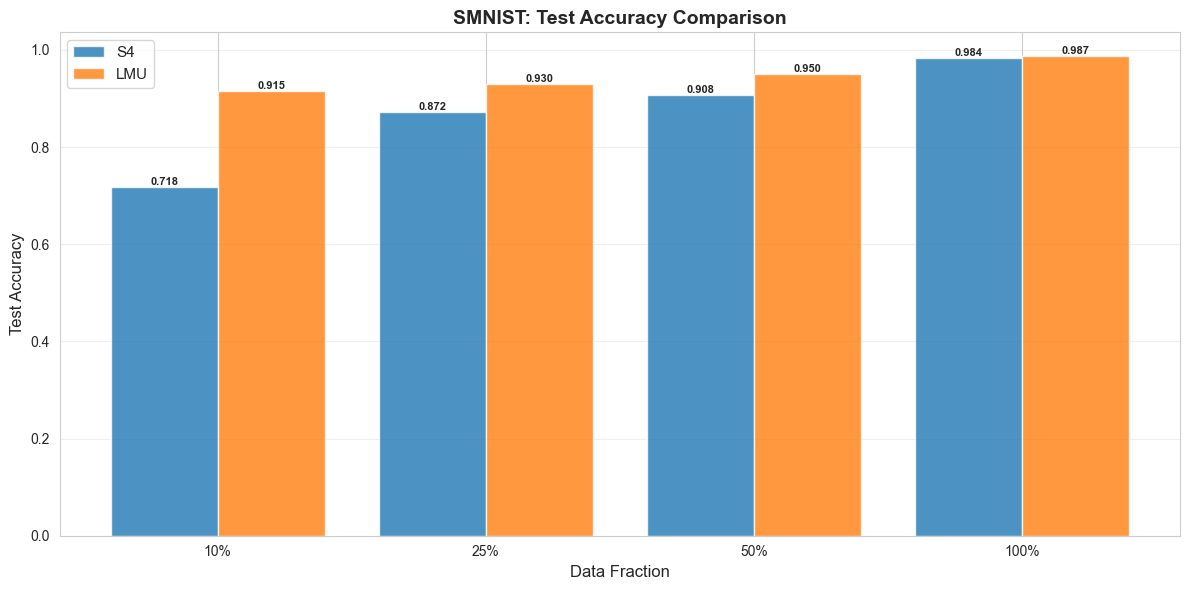

In [6]:
from src.eval.compare import plot_test_metric_comparison

plot_test_metric_comparison(
    all_results,
    metric_key='accuracy',
    title='SMNIST: Test Accuracy Comparison',
    ylabel='Test Accuracy',
    save_path=str(compare_folder / 'test_accuracy_comparison.png')
)

### Heatmap Visualization

Visual comparison of test accuracy across models and data fractions.


Plot saved to: figs/test_performance_heatmap.png


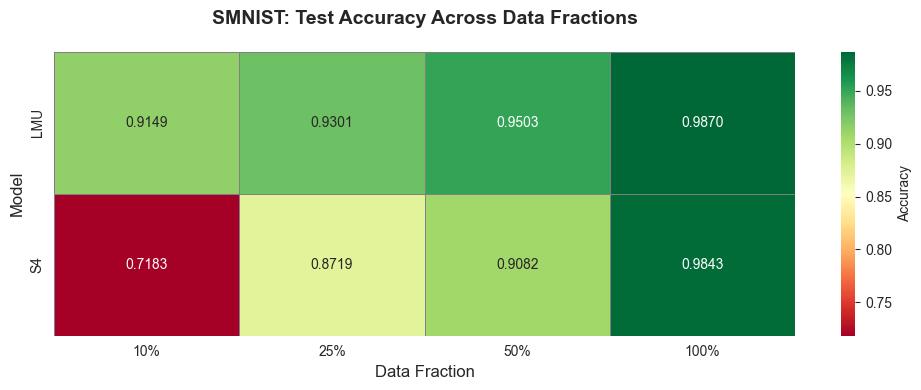

In [7]:
from src.eval.compare import plot_performance_heatmap

plot_performance_heatmap(
    all_results,
    metric_key='accuracy',
    title='SMNIST: Test Accuracy Across Data Fractions',
    annot_format='.4f',
    save_path=str(compare_folder / 'test_performance_heatmap.png')
)
